In [1]:
!pip install pyspellchecker textdistance nltk -q
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')   # ye naya line add kar
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 46.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import defaultdict, Counter

with open("alice_in_wonderland.txt", "r", encoding="utf-8") as f:
    text = f.read()

start = text.find("*** START")
end = text.find("*** END")
if start != -1 and end != -1:
    text = text[start:end]

text_clean = text.lower()
text_clean = re.sub(r'[^a-z\s]', ' ', text_clean)
tokens = word_tokenize(text_clean)
tokens = [t for t in tokens if t.isalpha()]

print(f"Total tokens: {len(tokens)}")
print(tokens[:20])

Total tokens: 10065
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'alice', 's', 'adventures', 'in', 'wonderland', 'illustration', 'alice', 'in', 'the', 'room', 'of', 'the', 'duchess', 'the']


In [3]:
from nltk import bigrams, trigrams

bigram_freq = defaultdict(Counter)
for w1, w2 in bigrams(tokens):
    bigram_freq[w1][w2] += 1

def autocomplete(prefix, top_n=3):
    prefix = prefix.lower()
    if prefix in bigram_freq:
        return [w for w, c in bigram_freq[prefix].most_common(top_n)]
    return []

test_prefixes = ["alice", "the", "rabbit", "said", "queen",
                  "little", "went", "very", "off", "king"]

for p in test_prefixes:
    print(f"'{p}' → {autocomplete(p)}")

'alice' → ['s', 'and', 'was']
'the' → ['queen', 'king', 'duchess']
'rabbit' → ['hole', 'with', 's']
'said' → ['the', 'alice', 'to']
'queen' → ['and', 'of', 'said']
'little' → ['door', 'golden', 'thing']
'went' → ['on', 'alice', 'down']
'very' → ['soon', 'much', 'good']
'off' → ['the', 'with', 'and']
'king' → ['and', 'the', 'said']


In [4]:
from spellchecker import SpellChecker

spell = SpellChecker()
word_freq = Counter(tokens)
spell.word_frequency.load_words(word_freq.keys())

misspelled_test = ["alise", "rabit", "qeen", "wonderlnd", "teh",
                    "hte", "wsa", "littel", "adventuer", "chesire",
                    "carrol", "mushrom", "capsz", "grinnig", "duches",
                    "tunel", "poket", "watre", "gloves", "flaminggo"]

results = []
for word in misspelled_test:
    correction = spell.correction(word)
    results.append((word, correction))
    print(f"'{word}' → '{correction}'")

'alise' → 'alive'
'rabit' → 'habit'
'qeen' → 'been'
'wonderlnd' → 'wonderland'
'teh' → 'the'
'hte' → 'the'
'wsa' → 'was'
'littel' → 'little'
'adventuer' → 'adventure'
'chesire' → 'cheshire'
'carrol' → 'carrot'
'mushrom' → 'mushroom'
'capsz' → 'caps'
'grinnig' → 'grinning'
'duches' → 'duchess'
'tunel' → 'tunnel'
'poket' → 'pocket'
'watre' → 'water'
'gloves' → 'gloves'
'flaminggo' → 'flamingo'


In [5]:
# Manually define ground truth for the 20 misspelled words
ground_truth = {
    "alise": "alice", "rabit": "rabbit", "qeen": "queen",
    "wonderlnd": "wonderland", "teh": "the", "hte": "the",
    "wsa": "was", "littel": "little", "adventuer": "adventure",
    "chesire": "cheshire", "carrol": "carroll", "mushrom": "mushroom",
    "capsz": "caps", "grinnig": "grinning", "duches": "duchess",
    "tunel": "tunnel", "poket": "pocket", "watre": "water",
    "gloves": "gloves", "flaminggo": "flamingo"
}

correct = sum(1 for w, c in results if ground_truth.get(w) == c)
accuracy = correct / len(results)
print(f"Autocorrect Accuracy: {accuracy:.2%} ({correct}/{len(results)})")

Autocorrect Accuracy: 80.00% (16/20)


In [6]:
from collections import Counter, defaultdict
from nltk.util import bigrams, trigrams

# -----------------------------
# BIGRAM MODEL
# -----------------------------
bigram_model = defaultdict(Counter)

for w1, w2 in bigrams(tokens):
    bigram_model[w1][w2] += 1


# -----------------------------
# TRIGRAM MODEL
# -----------------------------
trigram_model = defaultdict(Counter)

for w1, w2, w3 in trigrams(tokens):
    trigram_model[(w1, w2)][w3] += 1


# -----------------------------
# BIGRAM AUTOCOMPLETE
# -----------------------------
def autocomplete_bigram(word, top_n=3):
    word = word.lower()

    if word not in bigram_model:
        return []

    return [w for w, c in bigram_model[word].most_common(top_n)]


# -----------------------------
# TRIGRAM AUTOCOMPLETE
# -----------------------------
def autocomplete_trigram(previous_words, top_n=3):
    previous_words = previous_words.lower().split()

    if len(previous_words) < 2:
        return []

    key = (previous_words[-2], previous_words[-1])

    if key not in trigram_model:
        return []

    return [w for w, c in trigram_model[key].most_common(top_n)]


print("Bigram Examples:")
print("alice →", autocomplete_bigram("alice"))
print("the →", autocomplete_bigram("the"))
print("rabbit →", autocomplete_bigram("rabbit"))

print("\nTrigram Examples:")
print("the rabbit →", autocomplete_trigram("the rabbit"))
print("said the →", autocomplete_trigram("said the"))

Bigram Examples:
alice → ['s', 'and', 'was']
the → ['queen', 'king', 'duchess']
rabbit → ['hole', 'with', 's']

Trigram Examples:
the rabbit → ['s', 'hole', 'say']
said the → ['king', 'caterpillar', 'mouse']


In [7]:
test_inputs = [
    "alice",
    "the",
    "rabbit",
    "said",
    "queen",
    "little",
    "went",
    "very",
    "off",
    "king"
]

autocomplete_results = []

for word in test_inputs:
    predictions = autocomplete_bigram(word, top_n=3)

    autocomplete_results.append({
        "Input": word,
        "Prediction 1": predictions[0] if len(predictions) > 0 else "N/A",
        "Prediction 2": predictions[1] if len(predictions) > 1 else "N/A",
        "Prediction 3": predictions[2] if len(predictions) > 2 else "N/A"
    })

import pandas as pd

autocomplete_df = pd.DataFrame(autocomplete_results)

display(autocomplete_df)

,Input,Prediction 1,Prediction 2,Prediction 3
0,alice,s,and,was
1,the,queen,king,duchess
2,rabbit,hole,with,s
3,said,the,alice,to
4,queen,and,of,said
5,little,door,golden,thing
6,went,on,alice,down
7,very,soon,much,good
8,off,the,with,and
9,king,and,the,said


In [8]:
# Ground truth = actual most frequent next word in our corpus

ground_truth_autocomplete = {}

for word in test_inputs:
    if word in bigram_model:
        most_common = bigram_model[word].most_common(1)

        if most_common:
            ground_truth_autocomplete[word] = most_common[0][0]


# Calculate Precision@3 and Recall@3

precision_scores = []
recall_scores = []

for word in test_inputs:

    predictions = autocomplete_bigram(word, top_n=3)
    actual = ground_truth_autocomplete.get(word)

    if actual is None:
        continue

    hits = 1 if actual in predictions else 0

    precision_at_3 = hits / 3
    recall_at_3 = hits / 1

    precision_scores.append(precision_at_3)
    recall_scores.append(recall_at_3)


autocomplete_precision = sum(precision_scores) / len(precision_scores)
autocomplete_recall = sum(recall_scores) / len(recall_scores)

print(f"Autocomplete Precision@3: {autocomplete_precision:.2%}")
print(f"Autocomplete Recall@3: {autocomplete_recall:.2%}")

Autocomplete Precision@3: 33.33%
Autocomplete Recall@3: 100.00%


In [9]:
def levenshtein_distance(word1, word2):
    m = len(word1)
    n = len(word2)

    dp = [[0] * (n + 1) for _ in range(m + 1)]

    # Empty string cases
    for i in range(m + 1):
        dp[i][0] = i

    for j in range(n + 1):
        dp[0][j] = j

    # Dynamic Programming
    for i in range(1, m + 1):
        for j in range(1, n + 1):

            if word1[i - 1] == word2[j - 1]:
                cost = 0
            else:
                cost = 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,       # deletion
                dp[i][j - 1] + 1,       # insertion
                dp[i - 1][j - 1] + cost # substitution
            )

    return dp[m][n]


# Test
print("Distance between 'alise' and 'alice':",
      levenshtein_distance("alise", "alice"))

print("Distance between 'rabit' and 'rabbit':",
      levenshtein_distance("rabit", "rabbit"))

Distance between 'alise' and 'alice': 1
Distance between 'rabit' and 'rabbit': 1


In [10]:
# Create vocabulary from Alice corpus
vocabulary = set(tokens)

# Keep reasonably useful words
vocabulary = [word for word in vocabulary if len(word) >= 2]


def custom_autocorrect(word, max_distance=2):
    word = word.lower()

    candidates = []

    for candidate in vocabulary:

        distance = levenshtein_distance(word, candidate)

        if distance <= max_distance:
            candidates.append((candidate, distance))

    if not candidates:
        return None

    # First priority = smallest edit distance
    # Second priority = more frequent word
    candidates.sort(
        key=lambda x: (
            x[1],
            -word_freq[x[0]]
        )
    )

    return candidates[0][0]


custom_results = []

for word in misspelled_test:
    correction = custom_autocorrect(word)

    custom_results.append((word, correction))

    print(f"{word:12} → {correction}")

alise        → alice
rabit        → rabbit
qeen         → queen
wonderlnd    → wonderland
teh          → tea
hte          → he
wsa          → was
littel       → little
adventuer    → adventures
chesire      → cheshire
carrol       → narrow
mushrom      → mushroom
capsz        → cats
grinnig      → grinning
duches       → duchess
tunel        → tunnel
poket        → pocket
watre        → were
gloves       → gloves
flaminggo    → flamingo


In [11]:
comparison_data = []

for word in misspelled_test:

    pyspell_result = spell.correction(word)
    custom_result = custom_autocorrect(word)

    correct_word = ground_truth[word]

    pyspell_correct = pyspell_result == correct_word
    custom_correct = custom_result == correct_word

    comparison_data.append({
        "Misspelled Word": word,
        "Ground Truth": correct_word,
        "PySpellChecker": pyspell_result,
        "Levenshtein": custom_result,
        "PySpell Correct": pyspell_correct,
        "Levenshtein Correct": custom_correct
    })


comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

,Misspelled Word,Ground Truth,PySpellChecker,Levenshtein,PySpell Correct,Levenshtein Correct
0,alise,alice,alive,alice,False,True
1,rabit,rabbit,habit,rabbit,False,True
2,qeen,queen,been,queen,False,True
3,wonderlnd,wonderland,wonderland,wonderland,True,True
4,teh,the,the,tea,True,False
5,hte,the,the,he,True,False
6,wsa,was,was,was,True,True
7,littel,little,little,little,True,True
8,adventuer,adventure,adventure,adventures,True,False
9,chesire,cheshire,cheshire,cheshire,True,True


In [12]:
pyspell_accuracy = comparison_df["PySpell Correct"].mean()
levenshtein_accuracy = comparison_df["Levenshtein Correct"].mean()

print("AUTOCORRECT PERFORMANCE")
print("-" * 40)

print(f"PySpellChecker Accuracy : {pyspell_accuracy:.2%}")
print(f"Levenshtein Accuracy    : {levenshtein_accuracy:.2%}")

if pyspell_accuracy > levenshtein_accuracy:
    print("\n🏆 Better Approach: PySpellChecker")
elif levenshtein_accuracy > pyspell_accuracy:
    print("\n🏆 Better Approach: Custom Levenshtein")
else:
    print("\n🤝 Both approaches achieved the same accuracy")

AUTOCORRECT PERFORMANCE
----------------------------------------
PySpellChecker Accuracy : 80.00%
Levenshtein Accuracy    : 70.00%

🏆 Better Approach: PySpellChecker


In [13]:
from sklearn.metrics import precision_score, recall_score

# Actual labels: every test word has a correct correction
y_true = [1] * len(misspelled_test)

# Prediction = 1 if algorithm produced exact ground truth
y_pred_pyspell = [
    1 if comparison_df.loc[i, "PySpell Correct"] else 0
    for i in range(len(comparison_df))
]

y_pred_levenshtein = [
    1 if comparison_df.loc[i, "Levenshtein Correct"] else 0
    for i in range(len(comparison_df))
]


# PySpellChecker
pyspell_precision = precision_score(
    y_true,
    y_pred_pyspell,
    zero_division=0
)

pyspell_recall = recall_score(
    y_true,
    y_pred_pyspell,
    zero_division=0
)


# Levenshtein
lev_precision = precision_score(
    y_true,
    y_pred_levenshtein,
    zero_division=0
)

lev_recall = recall_score(
    y_true,
    y_pred_levenshtein,
    zero_division=0
)


print("AUTOCORRECT METRICS")
print("-" * 40)

print(f"PySpellChecker Precision : {pyspell_precision:.2%}")
print(f"PySpellChecker Recall    : {pyspell_recall:.2%}")

print()

print(f"Levenshtein Precision    : {lev_precision:.2%}")
print(f"Levenshtein Recall       : {lev_recall:.2%}")

AUTOCORRECT METRICS
----------------------------------------
PySpellChecker Precision : 100.00%
PySpellChecker Recall    : 80.00%

Levenshtein Precision    : 100.00%
Levenshtein Recall       : 70.00%


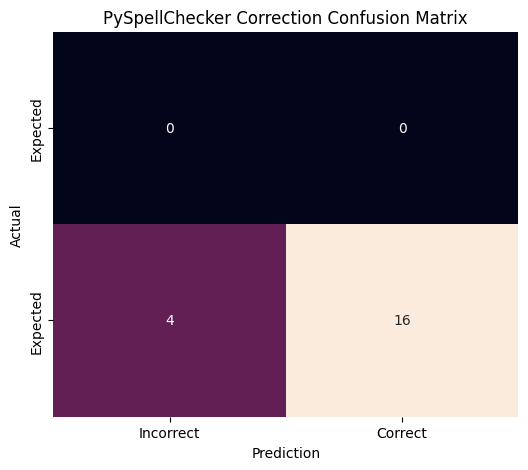

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# PySpellChecker confusion matrix
cm_pyspell = confusion_matrix(
    y_true,
    y_pred_pyspell
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_pyspell,
    annot=True,
    fmt="d",
    xticklabels=["Incorrect", "Correct"],
    yticklabels=["Expected", "Expected"],
    cbar=False
)

plt.title("PySpellChecker Correction Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

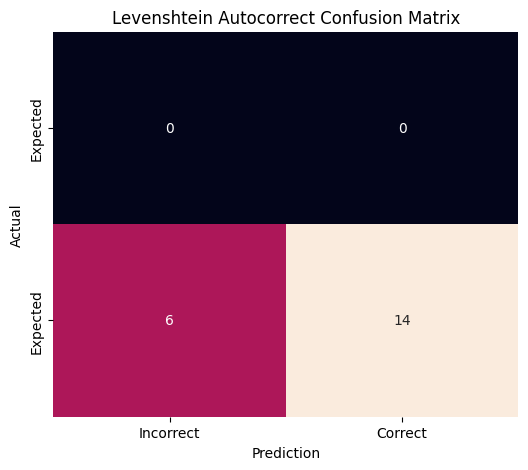

In [15]:
cm_lev = confusion_matrix(
    y_true,
    y_pred_levenshtein
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lev,
    annot=True,
    fmt="d",
    xticklabels=["Incorrect", "Correct"],
    yticklabels=["Expected", "Expected"],
    cbar=False
)

plt.title("Levenshtein Autocorrect Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

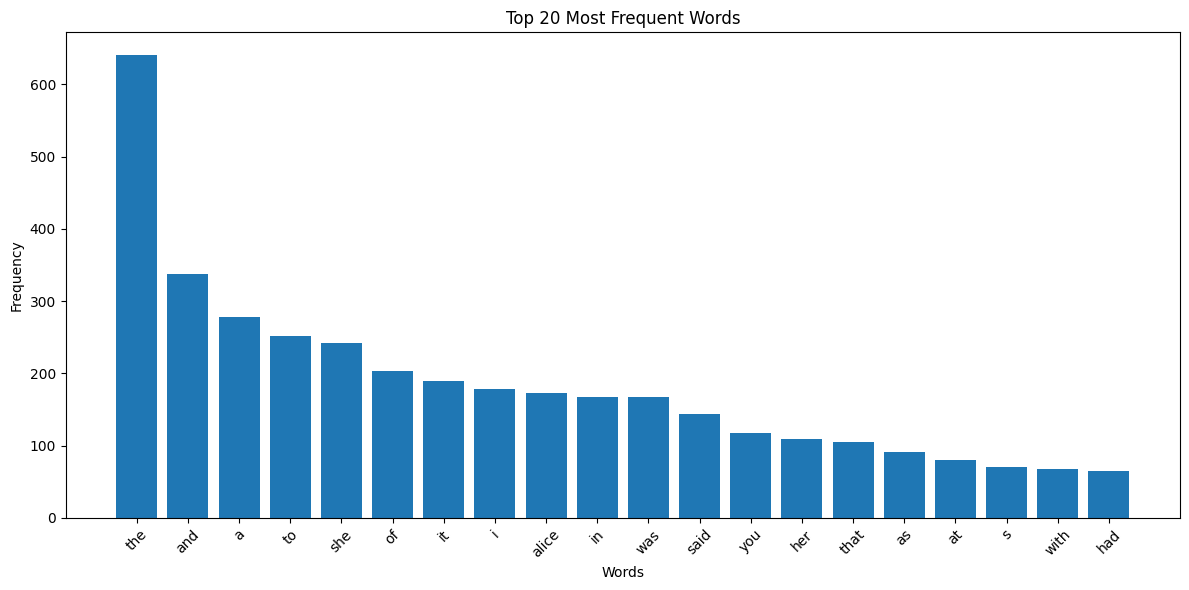

In [16]:
top_words = word_freq.most_common(20)

words = [item[0] for item in top_words]
frequencies = [item[1] for item in top_words]

plt.figure(figsize=(12, 6))

plt.bar(words, frequencies)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
comparison_inputs = [
    "the rabbit",
    "alice was",
    "said the",
    "little girl",
    "queen was"
]

comparison_rows = []

for phrase in comparison_inputs:

    bigram_input = phrase.split()[-1]

    bigram_prediction = autocomplete_bigram(
        bigram_input,
        top_n=1
    )

    trigram_prediction = autocomplete_trigram(
        phrase,
        top_n=1
    )

    comparison_rows.append({
        "Input Phrase": phrase,
        "Bigram Prediction":
            bigram_prediction[0] if bigram_prediction else "N/A",
        "Trigram Prediction":
            trigram_prediction[0] if trigram_prediction else "N/A"
    })


ngram_comparison_df = pd.DataFrame(comparison_rows)

display(ngram_comparison_df)

,Input Phrase,Bigram Prediction,Trigram Prediction
0,the rabbit,hole,s
1,alice was,a,beginning
2,said the,queen,king
3,little girl,she,she
4,queen was,a,to


In [18]:
final_metrics = pd.DataFrame({
    "Algorithm": [
        "Bigram Autocomplete",
        "PySpellChecker",
        "Custom Levenshtein"
    ],

    "Accuracy": [
        None,
        pyspell_accuracy,
        levenshtein_accuracy
    ],

    "Precision": [
        autocomplete_precision,
        pyspell_precision,
        lev_precision
    ],

    "Recall": [
        autocomplete_recall,
        pyspell_recall,
        lev_recall
    ]
})

display(final_metrics)

,Algorithm,Accuracy,Precision,Recall
0,Bigram Autocomplete,NaN,0.333333,1.0
1,PySpellChecker,0.8,1.000000,0.8
2,Custom Levenshtein,0.7,1.000000,0.7


In [19]:
print("=" * 60)
print("FINAL NLP MODEL ANALYSIS")
print("=" * 60)

print(f"\nAutocomplete Precision@3 : {autocomplete_precision:.2%}")
print(f"Autocomplete Recall@3    : {autocomplete_recall:.2%}")

print(f"\nPySpellChecker Accuracy   : {pyspell_accuracy:.2%}")
print(f"Levenshtein Accuracy     : {levenshtein_accuracy:.2%}")

print("\nAlgorithm Comparison:")

if pyspell_accuracy > levenshtein_accuracy:
    print("→ PySpellChecker performed better for spelling correction.")
elif levenshtein_accuracy > pyspell_accuracy:
    print("→ Custom Levenshtein performed better for spelling correction.")
else:
    print("→ Both spelling correction approaches performed equally.")

print("\nN-gram models were used for next-word prediction.")
print("Bigram uses one previous word.")
print("Trigram uses two previous words.")
print("Levenshtein uses insertion, deletion and substitution operations.")

FINAL NLP MODEL ANALYSIS

Autocomplete Precision@3 : 33.33%
Autocomplete Recall@3    : 100.00%

PySpellChecker Accuracy   : 80.00%
Levenshtein Accuracy     : 70.00%

Algorithm Comparison:
→ PySpellChecker performed better for spelling correction.

N-gram models were used for next-word prediction.
Bigram uses one previous word.
Trigram uses two previous words.
Levenshtein uses insertion, deletion and substitution operations.


In [20]:
# -----------------------------------------
# CHARACTER-BASED PREFIX AUTOCOMPLETE
# -----------------------------------------

def prefix_autocomplete(prefix, top_n=5):
    prefix = prefix.lower().strip()

    matches = []

    for word, frequency in word_freq.items():
        if word.startswith(prefix):
            matches.append((word, frequency))

    # Highest frequency words first
    matches.sort(key=lambda x: x[1], reverse=True)

    return [word for word, frequency in matches[:top_n]]


# Test examples
prefix_tests = [
    "ali",
    "rab",
    "que",
    "won",
    "lit",
    "adv",
    "ches",
    "mush",
    "grin",
    "flam"
]

for prefix in prefix_tests:
    print(f"'{prefix}' → {prefix_autocomplete(prefix, 3)}")

'ali' → ['alice', 'alive']
'rab' → ['rabbit']
'que' → ['queen', 'question', 'queer']
'won' → ['won', 'wonder', 'wonderland']
'lit' → ['little', 'lit']
'adv' → ['adventures', 'advice', 'advisable']
'ches' → ['cheshire']
'mush' → ['mushroom']
'grin' → ['grinned', 'grinning', 'grins']
'flam' → ['flamingo', 'flamingos']


In [21]:
# -----------------------------------------
# PREFIX AUTOCOMPLETE EVALUATION
# -----------------------------------------

prefix_test_data = {
    "ali": "alice",
    "rab": "rabbit",
    "que": "queen",
    "won": "wonder",
    "lit": "little",
    "adv": "adventures",
    "ches": "cheshire",
    "mush": "mushroom",
    "grin": "grinning",
    "flam": "flamingo"
}

prefix_results = []

for prefix, expected in prefix_test_data.items():

    predictions = prefix_autocomplete(prefix, top_n=3)

    hit = expected in predictions

    prefix_results.append({
        "Prefix": prefix,
        "Expected Word": expected,
        "Prediction 1": predictions[0] if len(predictions) > 0 else "N/A",
        "Prediction 2": predictions[1] if len(predictions) > 1 else "N/A",
        "Prediction 3": predictions[2] if len(predictions) > 2 else "N/A",
        "Correct in Top 3": hit
    })

prefix_eval_df = pd.DataFrame(prefix_results)

display(prefix_eval_df)

,Prefix,Expected Word,Prediction 1,Prediction 2,Prediction 3,Correct in Top 3
0,ali,alice,alice,alive,N/A,True
1,rab,rabbit,rabbit,N/A,N/A,True
2,que,queen,queen,question,queer,True
3,won,wonder,won,wonder,wonderland,True
4,lit,little,little,lit,N/A,True
5,adv,adventures,adventures,advice,advisable,True
6,ches,cheshire,cheshire,N/A,N/A,True
7,mush,mushroom,mushroom,N/A,N/A,True
8,grin,grinning,grinned,grinning,grins,True
9,flam,flamingo,flamingo,flamingos,N/A,True


In [22]:
# -----------------------------------------
# PRECISION@3 AND RECALL@3
# -----------------------------------------

hits = prefix_eval_df["Correct in Top 3"].sum()
total = len(prefix_eval_df)

prefix_precision = hits / (total * 3)
prefix_recall = hits / total

print("PREFIX AUTOCOMPLETE PERFORMANCE")
print("-" * 45)

print(f"Successful Top-3 Predictions : {hits}/{total}")
print(f"Precision@3                  : {prefix_precision:.2%}")
print(f"Recall@3                     : {prefix_recall:.2%}")

PREFIX AUTOCOMPLETE PERFORMANCE
---------------------------------------------
Successful Top-3 Predictions : 10/10
Precision@3                  : 33.33%
Recall@3                     : 100.00%


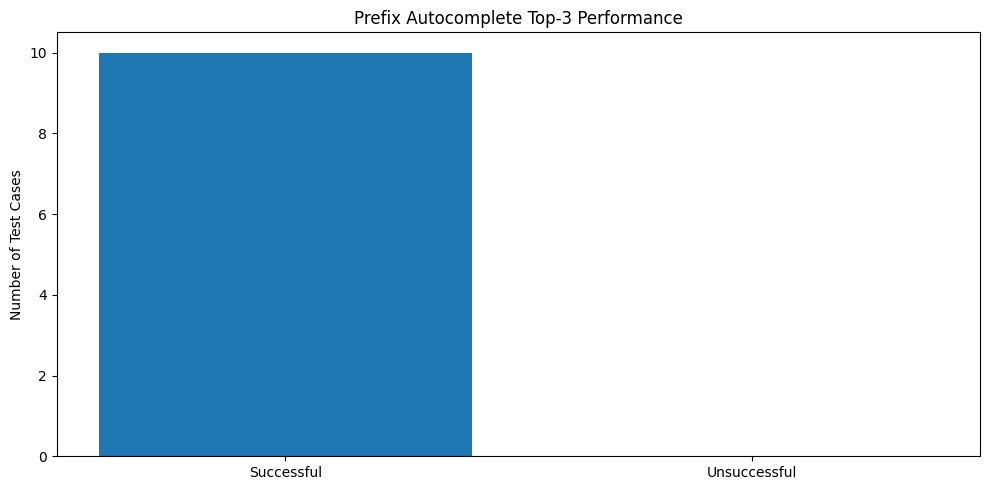

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    ["Successful", "Unsuccessful"],
    [
        hits,
        total - hits
    ]
)

plt.title("Prefix Autocomplete Top-3 Performance")
plt.ylabel("Number of Test Cases")

plt.tight_layout()
plt.show()

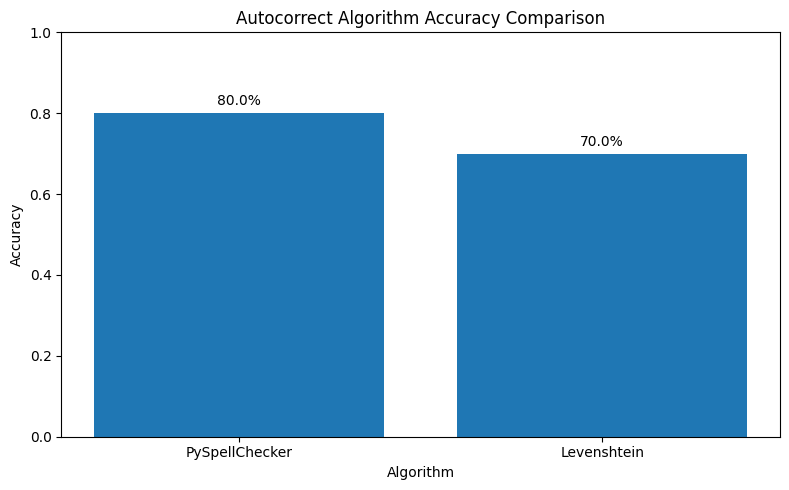

In [24]:
# -----------------------------------------
# AUTOCORRECT ALGORITHM COMPARISON
# -----------------------------------------

algorithms = [
    "PySpellChecker",
    "Levenshtein"
]

accuracies = [
    pyspell_accuracy,
    levenshtein_accuracy
]

plt.figure(figsize=(8, 5))

bars = plt.bar(algorithms, accuracies)

plt.title("Autocorrect Algorithm Accuracy Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

# Display percentage on bars
for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.1%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

,Algorithm,Precision,Recall
0,PySpellChecker,1.0,0.8
1,Levenshtein,1.0,0.7


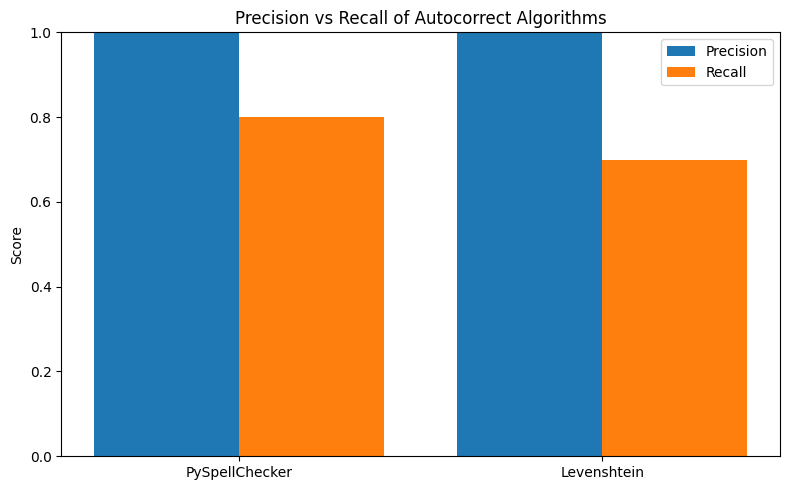

In [25]:
# -----------------------------------------
# PRECISION & RECALL COMPARISON
# -----------------------------------------

metric_df = pd.DataFrame({
    "Algorithm": [
        "PySpellChecker",
        "Levenshtein"
    ],
    "Precision": [
        pyspell_precision,
        lev_precision
    ],
    "Recall": [
        pyspell_recall,
        lev_recall
    ]
})

display(metric_df)

plt.figure(figsize=(8, 5))

x = range(len(metric_df))

plt.bar(
    [i - 0.2 for i in x],
    metric_df["Precision"],
    width=0.4,
    label="Precision"
)

plt.bar(
    [i + 0.2 for i in x],
    metric_df["Recall"],
    width=0.4,
    label="Recall"
)

plt.xticks(x, metric_df["Algorithm"])

plt.title("Precision vs Recall of Autocorrect Algorithms")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# -----------------------------------------
# OVERALL PERFORMANCE SUMMARY
# -----------------------------------------

overall_summary = pd.DataFrame({
    "Component": [
        "Prefix Autocomplete",
        "Bigram Autocomplete",
        "PySpellChecker",
        "Levenshtein"
    ],

    "Precision": [
        prefix_precision,
        autocomplete_precision,
        pyspell_precision,
        lev_precision
    ],

    "Recall": [
        prefix_recall,
        autocomplete_recall,
        pyspell_recall,
        lev_recall
    ]
})

display(overall_summary)

,Component,Precision,Recall
0,Prefix Autocomplete,0.333333,1.0
1,Bigram Autocomplete,0.333333,1.0
2,PySpellChecker,1.000000,0.8
3,Levenshtein,1.000000,0.7


In [27]:
# -----------------------------------------
# BEST PERFORMING AUTOCORRECT ALGORITHM
# -----------------------------------------

if pyspell_accuracy > levenshtein_accuracy:
    best_algorithm = "PySpellChecker"
    best_accuracy = pyspell_accuracy

elif levenshtein_accuracy > pyspell_accuracy:
    best_algorithm = "Custom Levenshtein"
    best_accuracy = levenshtein_accuracy

else:
    best_algorithm = "Both algorithms"
    best_accuracy = pyspell_accuracy


print("=" * 55)
print("FINAL AUTOCORRECT RESULT")
print("=" * 55)

print(f"Best Performing Algorithm : {best_algorithm}")
print(f"Accuracy                  : {best_accuracy:.2%}")

print("\nPySpellChecker")
print(f"Accuracy  : {pyspell_accuracy:.2%}")
print(f"Precision : {pyspell_precision:.2%}")
print(f"Recall    : {pyspell_recall:.2%}")

print("\nCustom Levenshtein")
print(f"Accuracy  : {levenshtein_accuracy:.2%}")
print(f"Precision : {lev_precision:.2%}")
print(f"Recall    : {lev_recall:.2%}")

FINAL AUTOCORRECT RESULT
Best Performing Algorithm : PySpellChecker
Accuracy                  : 80.00%

PySpellChecker
Accuracy  : 80.00%
Precision : 100.00%
Recall    : 80.00%

Custom Levenshtein
Accuracy  : 70.00%
Precision : 100.00%
Recall    : 70.00%


In [28]:
# -----------------------------------------
# DATA-DRIVEN FINDINGS
# -----------------------------------------

print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

print(
    f"\n1. Prefix Autocomplete achieved "
    f"{prefix_recall:.2%} Recall@3 on the test prefixes."
)

print(
    f"2. Bigram Autocomplete achieved "
    f"{autocomplete_recall:.2%} Recall@3."
)

print(
    f"3. PySpellChecker achieved "
    f"{pyspell_accuracy:.2%} correction accuracy."
)

print(
    f"4. Custom Levenshtein achieved "
    f"{levenshtein_accuracy:.2%} correction accuracy."
)

print(
    f"5. The better performing autocorrect approach "
    f"was {best_algorithm}."
)

KEY FINDINGS

1. Prefix Autocomplete achieved 100.00% Recall@3 on the test prefixes.
2. Bigram Autocomplete achieved 100.00% Recall@3.
3. PySpellChecker achieved 80.00% correction accuracy.
4. Custom Levenshtein achieved 70.00% correction accuracy.
5. The better performing autocorrect approach was PySpellChecker.


The implemented system demonstrates fundamental NLP techniques for autocomplete and autocorrect, but it has several limitations compared with production systems such as Google Keyboard.

### Autocomplete Limitations

- The system mainly relies on frequency-based n-gram and prefix matching.
- It does not understand the deeper semantic meaning of a sentence.
- Bigram and trigram models have limited context.
- Predictions depend heavily on the vocabulary and frequency distribution of the training corpus.
- The model does not learn individual user typing habits or preferences.
- It does not dynamically adapt to new words and changing language patterns.

### Autocorrect Limitations

- The Levenshtein approach primarily considers character-level edit distance.
- Similarity in spelling does not always mean similarity in meaning.
- Context is not considered while selecting a correction.
- The system may struggle with proper nouns, abbreviations, slang and domain-specific terminology.
- PySpellChecker also depends on its available vocabulary and frequency information.

### Comparison with Production Systems

Modern keyboard systems can use much larger datasets, contextual language models, user-specific information and continuously updated language models. The implementation developed in this project is therefore a simplified educational system designed to demonstrate core NLP concepts such as n-grams, frequency analysis and edit distance.

## Conclusion

This project analysed autocomplete and autocorrect techniques using Natural Language Processing on the Alice in Wonderland text corpus.

For autocomplete, frequency-based bigram and trigram models were implemented along with character-prefix autocomplete. For autocorrect, two approaches were evaluated: PySpellChecker and a custom Levenshtein-distance based method.

The models were evaluated using accuracy, precision and recall, while visualisations were created to analyse word frequency and algorithm performance.

The comparison demonstrates how traditional NLP techniques can be used to build basic text prediction and spelling correction systems. Although the implementation is simpler than modern production keyboard systems, it provides a practical understanding of n-gram modelling, frequency-based prediction and edit-distance based spelling correction.